In [1]:
!pip -q install -U transformers datasets accelerate evaluate scikit-learn sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 117.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 42.9 MB/s eta 0:00:00


In [48]:
#Libraries
import os
import random
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from transformers import set_seed
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [4]:
#Setup reproducubility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed:", SEED)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

Seed: 42
PyTorch: 2.11.0+cu128
CUDA: 12.8
GPU: NVIDIA A100-SXM4-40GB


In [6]:
#Load dataset
train_df = pd.read_csv("/content/phishing_train.csv")
val_df = pd.read_csv("/content/phishing_validation.csv")
test_df = pd.read_csv("/content/phishing_test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (14015, 4)
Validation: (1752, 4)
Test: (1752, 4)


In [15]:
#Convert dataset
train_dataset = Dataset.from_pandas(
    train_df[["processed_text", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["processed_text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["processed_text", "label"]],
    preserve_index=False
)
print("Converted")

Converted


In [40]:
#Tokenize
MAX_LENGTH = 512
def tokenize_function(examples):
    return tokenizer(
        examples["processed_text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["processed_text"]
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["processed_text"]
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["processed_text"]
)

print(train_tokenized)

Map:   0%|          | 0/14015 [00:00<?, ? examples/s]

Map:   0%|          | 0/1752 [00:00<?, ? examples/s]

Map:   0%|          | 0/1752 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 14015
})


In [41]:
#Load the model
MODEL_NAME = "microsoft/deberta-v3-large"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    torch_dtype=torch.float32
)

print("Model dtype:", next(model.parameters()).dtype)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.de

Model dtype: torch.float32


In [42]:
#Set metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        pos_label=1,
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
    print("Done")

In [43]:
nan_params = []

for name, param in model.named_parameters():
    if not torch.isfinite(param).all():
        nan_params.append(name)

print("NaN/Inf parameters:", len(nan_params))

NaN/Inf parameters: 0


In [44]:
#Trainer
training_args = TrainingArguments(
    output_dir="/content/deberta_v3_large_results",

    num_train_epochs=3,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    gradient_accumulation_steps=2,

    learning_rate=1e-5,
    weight_decay=0.01,

    warmup_steps=263,
    max_grad_norm=1.0,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    fp16=False,
    bf16=False,

    optim="adamw_torch",

    seed=42,
    data_seed=42,

    report_to="none",
    save_total_limit=2
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

print("DeBERTa Trainer ready.")

DeBERTa Trainer ready.


In [45]:
print("Model dtype:", next(trainer.model.parameters()).dtype)
print("Optimizer:", trainer.args.optim)

Model dtype: torch.float32
Optimizer: OptimizerNames.ADAMW_TORCH


In [46]:
#Train model
train_result = trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.090342,0.059636,0.989155,0.980333,0.990826,0.985551
2,0.031313,0.065813,0.988584,0.977410,0.992355,0.984825
3,0.014909,0.048691,0.993151,0.996904,0.984709,0.990769


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [47]:
#Evaluate on test set
test_results = trainer.evaluate(
    test_tokenized,
    metric_key_prefix="test"
)

print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.014909,0.043410,3,0.993721,0.989346,0.993884,0.991609


{'test_loss': 0.04341038689017296, 'test_accuracy': 0.9937214611872146, 'test_precision': 0.989345509893455, 'test_recall': 0.9938837920489296, 'test_f1': 0.9916094584286804}


                precision    recall  f1-score   support

    Safe Email     0.9963    0.9936    0.9950      1098
Phishing Email     0.9893    0.9939    0.9916       654

      accuracy                         0.9937      1752
     macro avg     0.9928    0.9938    0.9933      1752
  weighted avg     0.9937    0.9937    0.9937      1752

Confusion Matrix:
[[1091    7]
 [   4  650]]


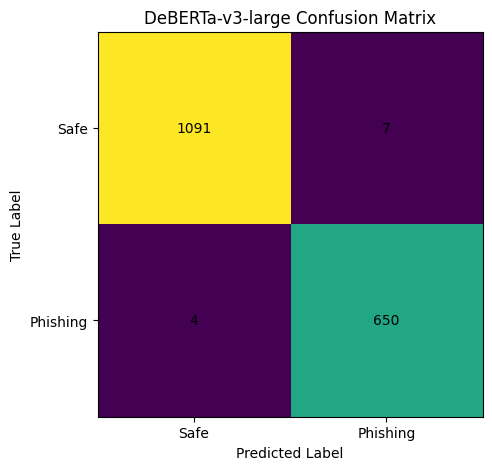

In [49]:
#Classification report and confusion matrix
predictions = trainer.predict(test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=["Safe Email", "Phishing Email"],
    digits=4
))
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("DeBERTa-v3-large Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Safe", "Phishing"])
plt.yticks([0, 1], ["Safe", "Phishing"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()